<a href="https://www.kaggle.com/code/sonawanelalitsunil/flipkart-product-list-ml-51-40?scriptVersionId=232121203" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flipkart-product-list/flipkart_products_20250405.csv


## Title : Flipkart Product List

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/flipkart-product-list/flipkart_products_20250405.csv')

In [3]:
df.head()

,Product Name,Price (₹),Rating (★),Number of Buyers,Total Sold,Available Stock,Main Category,Sub Category,Discount (%),Seller,Return Policy,Product URL
0,Krishnamurthy-Devan Laboriosam Ultra Smartphon...,142247.04,3.2,7348,4812,364,Electronics,Smartphones,45,RetailNet,False,https://www.flipkart.com/Krishnamurthy-Devan-L...
1,Nanda-Mahal Dignissimos Lite Laptops 1,186922.43,4.1,2342,881,145,Electronics,Laptops,55,Flipkart Assured,False,https://www.flipkart.com/Nanda-Mahal-Dignissim...
2,Choudhury LLC Amet Plus Decor 15,11843.41,5.0,739,2580,206,Home,Decor,58,SuperComNet,True,https://www.flipkart.com/Choudhury-LLC-Amet-Pl...
3,Borah LLC Accusantium Lite Smartphones 9,10864.31,4.8,1543,4562,1585,Electronics,Smartphones,0,ElectroWorld,False,https://www.flipkart.com/Borah-LLC-Accusantium...
4,Murty Inc Placeat Pro Smartwatches 8,32950.41,4.5,7702,4925,1064,Electronics,Smartwatches,18,MobileHub,False,https://www.flipkart.com/Murty-Inc-Placeat-Pro...


In [4]:
df.tail()

,Product Name,Price (₹),Rating (★),Number of Buyers,Total Sold,Available Stock,Main Category,Sub Category,Discount (%),Seller,Return Policy,Product URL
4995,Sampath-Sama Repellat Pro T-Shirts 11,1620.65,4.9,568,5322,2126,Fashion,T-Shirts,9,RetailNet,False,https://www.flipkart.com/Sampath-Sama-Repellat...
4996,"Sekhon, Sachdeva and Chakrabarti Hic Plus Shoe...",18414.64,4.4,9103,7361,3133,Fashion,Shoes,44,ElectroWorld,False,"https://www.flipkart.com/Sekhon,-Sachdeva-and-..."
4997,"Mittal, Sinha and Kumer Asperiores Lite Washin...",24841.94,3.1,6124,4164,900,Appliances,Washing Machines,8,SuperComNet,False,"https://www.flipkart.com/Mittal,-Sinha-and-Kum..."
4998,Suresh Ltd Voluptatibus Plus Furniture 13,25177.89,3.4,4536,1645,414,Home,Furniture,0,MobileHub,True,https://www.flipkart.com/Suresh-Ltd-Voluptatib...
4999,Padmanabhan Inc Harum Lite Furniture 15,34636.40,3.5,6309,6791,1713,Home,Furniture,14,Flipkart Assured,False,https://www.flipkart.com/Padmanabhan-Inc-Harum...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Name      5000 non-null   object 
 1   Price (₹)         5000 non-null   float64
 2   Rating (★)        5000 non-null   float64
 3   Number of Buyers  5000 non-null   int64  
 4   Total Sold        5000 non-null   int64  
 5   Available Stock   5000 non-null   int64  
 6   Main Category     5000 non-null   object 
 7   Sub Category      5000 non-null   object 
 8   Discount (%)      5000 non-null   int64  
 9   Seller            5000 non-null   object 
 10  Return Policy     5000 non-null   bool   
 11  Product URL       5000 non-null   object 
dtypes: bool(1), float64(2), int64(4), object(5)
memory usage: 434.7+ KB


In [6]:
df.describe()

,Price (₹),Rating (★),Number of Buyers,Total Sold,Available Stock,Discount (%)
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,35884.094350,4.003640,5044.425600,5005.066200,1250.870200,26.208000
std,39867.681428,0.584742,2886.016013,2897.042048,1109.872427,23.484332
min,100.450000,3.000000,11.000000,50.000000,0.000000,0.000000
25%,12275.502500,3.500000,2553.750000,2495.000000,323.750000,0.000000
50%,27761.010000,4.000000,5099.500000,4972.500000,916.000000,23.000000
75%,42852.247500,4.500000,7575.500000,7571.500000,1934.250000,47.000000
max,249158.910000,5.000000,10000.000000,10000.000000,4924.000000,70.000000


In [7]:
df.dtypes

Product Name         object
Price (₹)           float64
Rating (★)          float64
Number of Buyers      int64
Total Sold            int64
Available Stock       int64
Main Category        object
Sub Category         object
Discount (%)          int64
Seller               object
Return Policy          bool
Product URL          object
dtype: object

In [8]:
df.shape

(5000, 12)

In [9]:
df.isnull().sum()

Product Name        0
Price (₹)           0
Rating (★)          0
Number of Buyers    0
Total Sold          0
Available Stock     0
Main Category       0
Sub Category        0
Discount (%)        0
Seller              0
Return Policy       0
Product URL         0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Product Name', 'Price (₹)', 'Rating (★)', 'Number of Buyers',
       'Total Sold', 'Available Stock', 'Main Category', 'Sub Category',
       'Discount (%)', 'Seller', 'Return Policy', 'Product URL'],
      dtype='object')

## Data visualizations

Text(0.5, 0, 'Price (₹)')

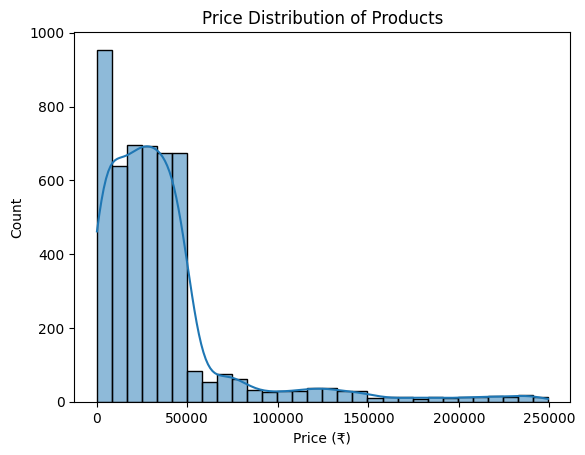

In [12]:
sns.histplot(df['Price (₹)'], bins=30, kde=True)
plt.title("Price Distribution of Products")
plt.xlabel("Price (₹)")

Text(0.5, 1.0, 'Price vs. Rating')

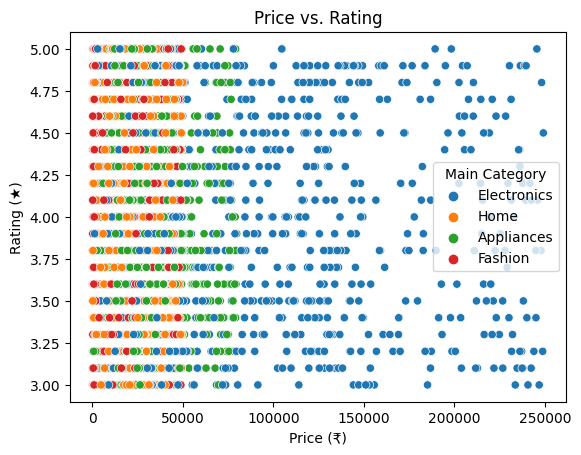

In [13]:
sns.scatterplot(data=df, x='Price (₹)', y='Rating (★)', hue='Main Category')
plt.title("Price vs. Rating")

Text(0.5, 1.0, 'Total Sold vs. Rating with Discount Size')

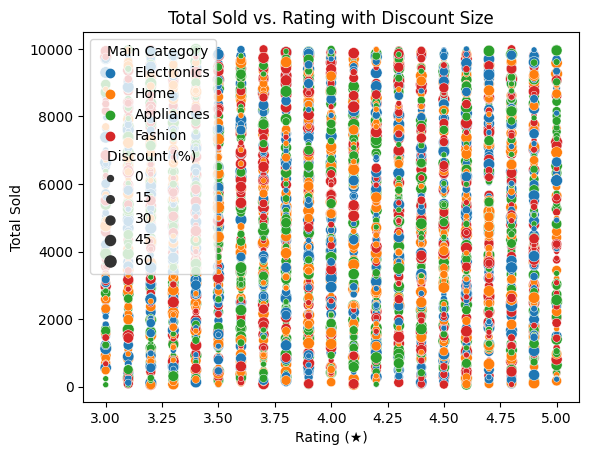

In [14]:
sns.scatterplot(data=df, x='Rating (★)', y='Total Sold', size='Discount (%)', hue='Main Category')
plt.title("Total Sold vs. Rating with Discount Size")


Text(0.5, 1.0, 'Buyers vs. Total Sold')

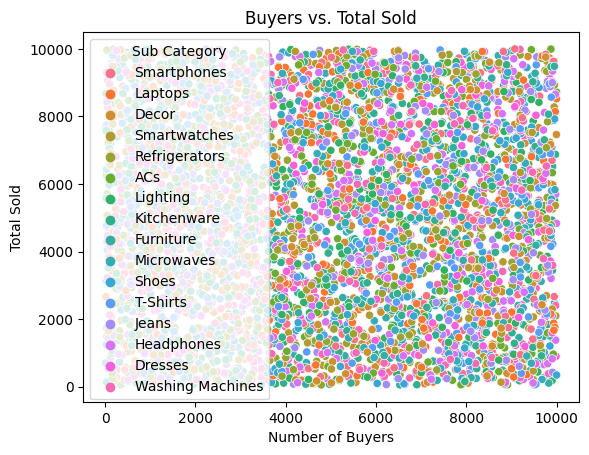

In [15]:
sns.scatterplot(data=df, x='Number of Buyers', y='Total Sold', hue='Sub Category')
plt.title("Buyers vs. Total Sold")


Text(0.5, 1.0, 'Available Stock by Sub Category')

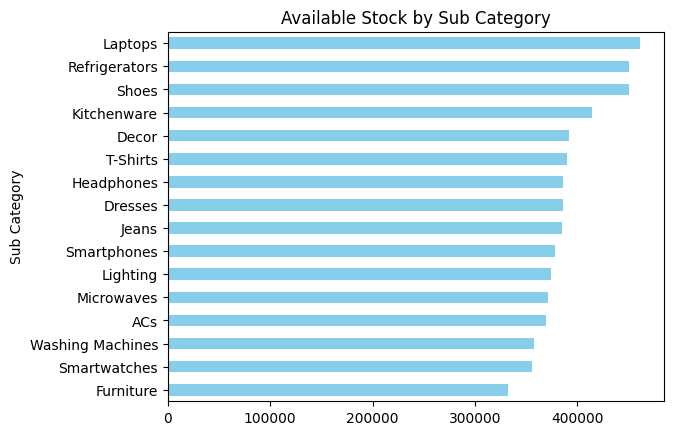

In [16]:
stock_by_category = df.groupby('Sub Category')['Available Stock'].sum().sort_values()
stock_by_category.plot(kind='barh', color='skyblue')
plt.title("Available Stock by Sub Category")


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 [Text(0, 0, 'Smartphones'),
  Text(1, 0, 'Laptops'),
  Text(2, 0, 'Decor'),
  Text(3, 0, 'Smartwatches'),
  Text(4, 0, 'Refrigerators'),
  Text(5, 0, 'ACs'),
  Text(6, 0, 'Lighting'),
  Text(7, 0, 'Kitchenware'),
  Text(8, 0, 'Furniture'),
  Text(9, 0, 'Microwaves'),
  Text(10, 0, 'Shoes'),
  Text(11, 0, 'T-Shirts'),
  Text(12, 0, 'Jeans'),
  Text(13, 0, 'Headphones'),
  Text(14, 0, 'Dresses'),
  Text(15, 0, 'Washing Machines')])

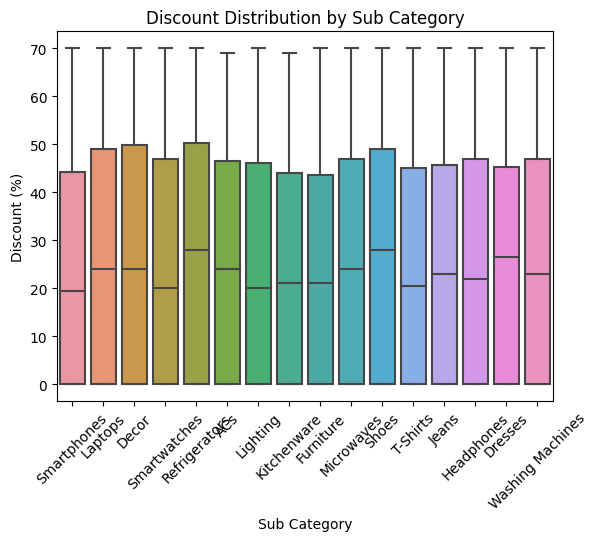

In [17]:
sns.boxplot(data=df, x='Sub Category', y='Discount (%)')
plt.title("Discount Distribution by Sub Category")
plt.xticks(rotation=45)


Text(0.5, 1.0, 'Top 10 Sellers by Total Sold')

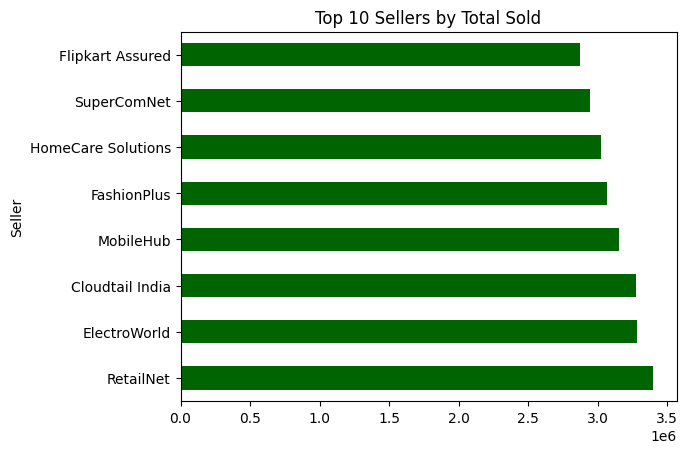

In [18]:
top_sellers = df.groupby('Seller')['Total Sold'].sum().sort_values(ascending=False).head(10)
top_sellers.plot(kind='barh', color='darkgreen')
plt.title("Top 10 Sellers by Total Sold")


Text(0.5, 1.0, 'Return Policy Distribution')

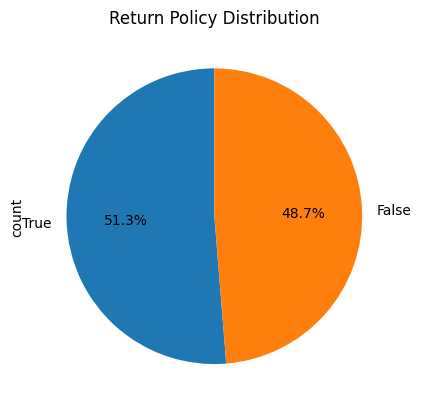

In [19]:
df['Return Policy'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title("Return Policy Distribution")


Text(0.5, 1.0, 'Average Price by Main Category')

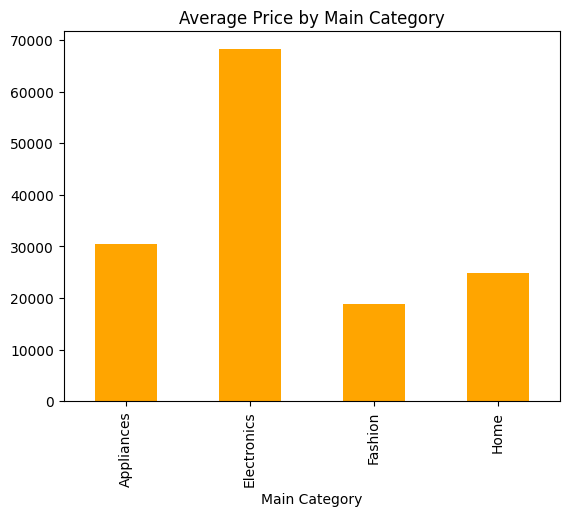

In [20]:
avg_price = df.groupby('Main Category')['Price (₹)'].mean()
avg_price.plot(kind='bar', color='orange')
plt.title("Average Price by Main Category")


In [21]:
df['Product Link'] = df['Product Name'] + ' | ' + df['Product URL']
display(df[['Product Link', 'Price (₹)', 'Rating (★)', 'Discount (%)']].head(10))


,Product Link,Price (₹),Rating (★),Discount (%)
0,Krishnamurthy-Devan Laboriosam Ultra Smartphon...,142247.04,3.2,45
1,Nanda-Mahal Dignissimos Lite Laptops 1 | https...,186922.43,4.1,55
2,Choudhury LLC Amet Plus Decor 15 | https://www...,11843.41,5.0,58
3,Borah LLC Accusantium Lite Smartphones 9 | htt...,10864.31,4.8,0
4,Murty Inc Placeat Pro Smartwatches 8 | https:/...,32950.41,4.5,18
5,Verma-Pillai Ipsa Pro Refrigerators 15 | https...,26497.18,4.4,0
6,Patla-Guha Exercitationem Ultra ACs 5 | https:...,6837.73,3.8,0
7,Aggarwal Group Dignissimos Lite ACs 6 | https:...,40548.35,3.1,52
8,Krishna-Tandon Quo Ultra Lighting 12 | https:/...,38045.07,4.9,32
9,Cheema and Sons Distinctio Pro Decor 1 | https...,9370.93,3.8,0


## Predictive modling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

🔍 Logistic Regression
✅ Accuracy: 46.10%
🧩 Confusion Matrix:
[[124 396]
 [143 337]]


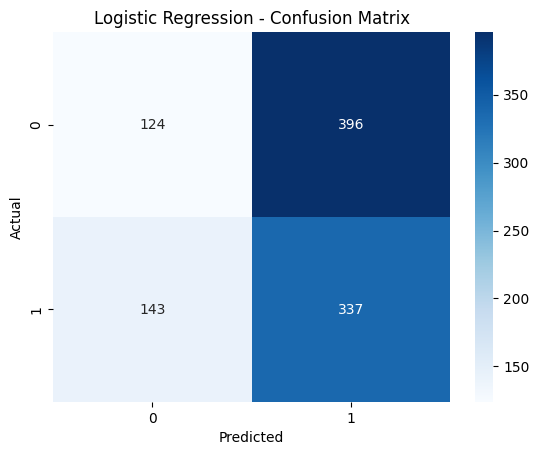

🔍 Decision Tree
✅ Accuracy: 47.80%
🧩 Confusion Matrix:
[[232 288]
 [234 246]]


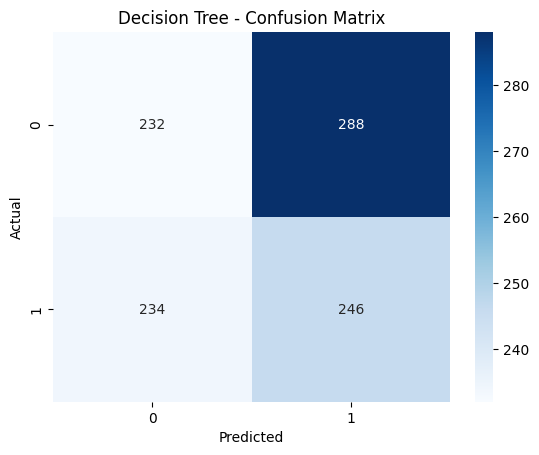

🔍 Random Forest
✅ Accuracy: 47.50%
🧩 Confusion Matrix:
[[211 309]
 [216 264]]


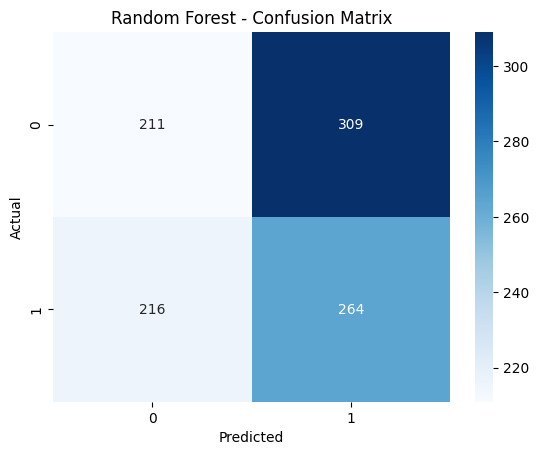

🔍 Gradient Boosting
✅ Accuracy: 48.40%
🧩 Confusion Matrix:
[[169 351]
 [165 315]]


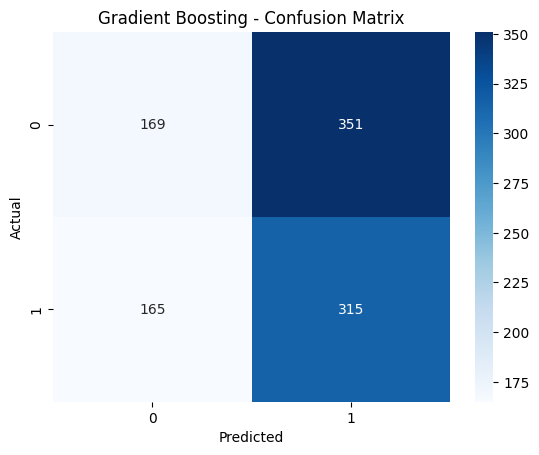

🔍 Support Vector Machine
✅ Accuracy: 48.30%
🧩 Confusion Matrix:
[[  9 511]
 [  6 474]]


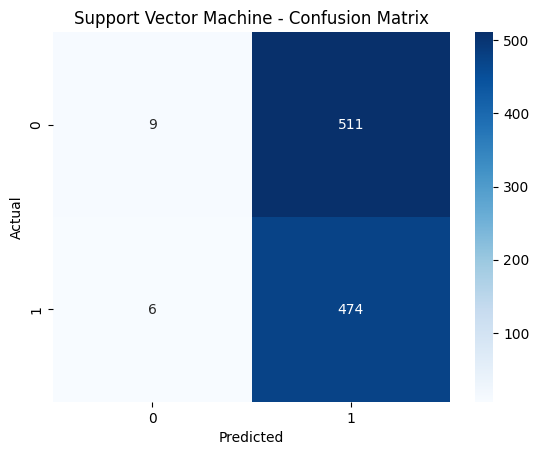

🔍 K-Nearest Neighbors
✅ Accuracy: 51.40%
🧩 Confusion Matrix:
[[250 270]
 [216 264]]


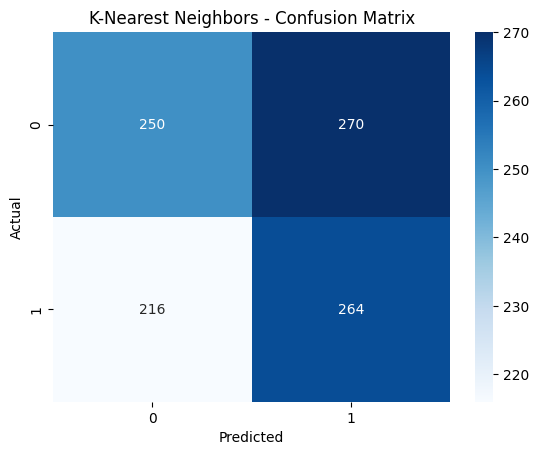

In [23]:
# Drop URLs (not needed for modeling)
df.drop(columns=['Product URL'], inplace=True)

# Label encode all object (categorical) columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Example: Predict whether product is "Returnable" or not
# Assuming Return Policy values like: 0 = No Return, 1 = 7 Days, 2 = 10 Days etc.
# We'll convert this into binary: Returnable (1) vs Not Returnable (0)
df['Returnable'] = df['Return Policy'].apply(lambda x: 1 if x != 0 else 0)
df.drop(columns=['Return Policy'], inplace=True)

# Define features and target
X = df.drop(columns=['Returnable'])
y = df['Returnable']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Classifiers to test
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Training, prediction, and accuracy evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)

    print(f"🔍 {name}")
    print(f"✅ Accuracy: {acc:.2f}%")
    print("🧩 Confusion Matrix:")
    print(cm)
    
    # Optional: plot confusion matrix
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Thank you...pls upvote!!